['\ufeffwt RDM' 'wt' 'ctrA' 'osp' 'ctrA/ctrA']


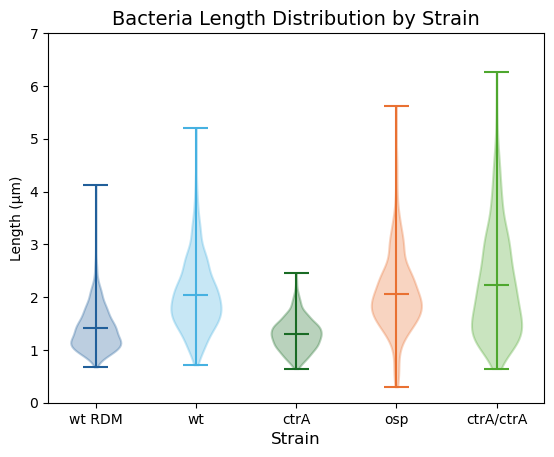

In [ ]:
# This code reads an csv file and plots violin plots for each of the categories.
# It assumes the first row in the "csv" file contains the category names, 
# and the rest of the rows are the values. The values per category have different lengths. 
# For example a file with the lengths of different bacteria strengths.
# python version  3.12.2
# 06/13/26

import numpy as np
import matplotlib.pyplot as plt

filename =  'yourfilename.cvs' # i.e. 'Bacteria_longitudes.csv'


#1. Read the category names on the first row
names = np.genfromtxt(filename, delimiter = ",", max_rows=1, dtype=str)
print(names) # check this are the names 

#2. Read the data, skip the header row. 
#  empty cells become nan 
data = np.genfromtxt(filename, delimiter=",", skip_header=1, filling_values=np.nan)

#3. Split into 5 columns and drop nan from each independently 
# This is what handles the uneven column lengths
columns = [col[~np.isnan(col)] for col in data.T]


# 4 Define and customized one RGB color per category 
colors = np.array([
[33,95,154], # category 1 (RDM)
[70,177,225], # category 2  (wt)
[25,107,36], # category3 (ctrA)
[233,113,50], # category 4 (osp)
[78,167,46], # category 5 (ctrA/ctrA)
])

colors = colors/255 # to match 0-1 values

# 5. plot the Violin Plot

fig, ax = plt.subplots()
parts = ax.violinplot(columns, showmeans=True)

# 6. Color each violin body individually.
for body, color in zip(parts['bodies'], colors):
    body.set_facecolor((*color, 0.8))   # translucent fill
    body.set_edgecolor(color)           # solid edge
    body.set_linewidth(1.5)

# 7. Color the mean + min/max bar lines per category.
#    Each is one LineCollection; pass a list of colors, one per violin.
for partname in ('cmeans', 'cbars', 'cmins', 'cmaxes'):
    if partname in parts:
        parts[partname].set_color(colors)
        parts[partname].set_linewidth(1.5)

ax.set_xticks(range(1, len(names) + 1))
ax.set_xticklabels(names)
ax.set_ylim(0.0, 7.0)
plt.xlabel("Strain", fontsize=12)
plt.ylabel("Length (\u00b5m)", fontsize=10)
plt.title("Bacteria Length Distribution by Strain", fontsize=14)

#8. Save the graph as a png & svg file 
fig.savefig('violinplot.png', dpi=300, bbox_inches='tight')
fig.savefig('violinplot.svg', bbox_inches='tight')
plt.show()


